# 07 — Modelagem Preditiva

## Objetivo

Este notebook tem como objetivo desenvolver e avaliar modelos preditivos para estimar a **taxa de aprovação das escolas públicas de Ensino Fundamental de Porto Alegre** a partir de características escolares disponíveis na base analítica consolidada.

A modelagem segue a estrutura definida no projeto, utilizando os anos de **2018 a 2022 para treinamento** e o ano de **2023 para teste**, preservando a ordem temporal dos dados.

Serão avaliados posteriormente três algoritmos:

- Regressão Linear;
- Árvore de Decisão;
- Random Forest.

Os modelos serão comparados também com uma linha de base simples baseada na média histórica da taxa de aprovação.

A avaliação será realizada por meio das métricas:

- MAE — Erro Absoluto Médio;
- RMSE — Raiz do Erro Quadrático Médio;
- R² — Coeficiente de Determinação.

> A análise possui caráter preditivo e associativo. Os resultados não devem ser interpretados como evidência de relação causal entre as características escolares e o desempenho.

---

## 1. Carregamento da base analítica

Nesta primeira etapa são importadas as bibliotecas necessárias para preparação dos dados, construção dos modelos e avaliação de desempenho.

Em seguida, é carregada a base analítica consolidada gerada nas etapas anteriores do projeto.

Também são realizadas verificações iniciais para confirmar:

- a dimensão da base;
- os anos disponíveis;
- a quantidade de escolas distintas;
- a quantidade de registros com taxa de aprovação válida.

Essas validações garantem que a modelagem será executada sobre a mesma base utilizada nas análises exploratórias e nos indicadores do Power BI.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Carregamento da base analítica
# ============================================================

BASE_DIR = Path.cwd().parent
CAMINHO_BASE = BASE_DIR / "data" / "processed" / "base_analitica_escola_ano.csv"

df = pd.read_csv(CAMINHO_BASE)

print("Dimensão da base:", df.shape)
print("Período:", sorted(df["ano"].unique()))
print("Escolas:", df["codigo_escola"].nunique())
print("Taxa de aprovação válida:", df["taxa_aprovacao"].notna().sum())

display(df.head())

Dimensão da base: (1621, 51)
Período: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Escolas: 276
Taxa de aprovação válida: 1571


,ano,uf,municipio,codigo_municipio,codigo_escola,nome_escola,dependencia_administrativa,localizacao,situacao_funcionamento,IN_AGUA_POTAVEL,...,QT_DOC_FUND_AF,QT_TUR_FUND,QT_TUR_FUND_AI,QT_TUR_FUND_AF,taxa_aprovacao,taxa_reprovacao,taxa_abandono,media_alunos_fund,media_alunos_ai,media_alunos_af
0,2018,RS,Porto Alegre,4314902,43000479,E E IND ENS FUN TUPE PAN,Estadual,1,1,0,...,2,2,0,2,91.7,8.3,0.0,6.0,NaN,NaN
1,2018,RS,Porto Alegre,4314902,43001254,E E IND ENS FUN PINDO POTY,Estadual,1,1,0,...,1,2,1,1,100.0,0.0,0.0,1.5,1.0,NaN
2,2018,RS,Porto Alegre,4314902,43005047,E E IND ENS FUN KA AGUY MIRI,Estadual,1,1,0,...,2,2,0,2,100.0,0.0,0.0,3.0,NaN,NaN
3,2018,RS,Porto Alegre,4314902,43048200,EMEF PORTO NOVO,Municipal,1,1,0,...,8,13,9,4,78.0,22.0,0.0,26.9,26.0,29.0
4,2018,RS,Porto Alegre,4314902,43104932,COLEGIO DE APLICACAO UFRGS,Federal,1,1,0,...,39,12,5,7,88.5,11.5,0.0,24.7,20.0,28.0


## 2. Seleção preliminar das variáveis

Antes da construção dos modelos, é necessário identificar quais variáveis da base analítica poderão ser utilizadas como atributos preditores.

A variável-alvo será:

- `taxa_aprovacao`

Nesta etapa, são verificadas as colunas disponíveis e a quantidade de valores ausentes em cada variável. Essa análise evita incluir campos inadequados, redundantes ou com problemas de qualidade na modelagem.

Também é importante evitar variáveis que possuam relação matemática direta com a taxa de aprovação, como:

- taxa de reprovação;
- taxa de abandono.

Essas variáveis não serão utilizadas como preditores, pois fazem parte da própria composição do indicador de rendimento e poderiam gerar vazamento de informação (*data leakage*).

In [2]:

print("Total de colunas:", len(df.columns))

for coluna in df.columns:
    print(coluna)

print("\nValores ausentes por coluna:")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("valores_ausentes")
)

Total de colunas: 51
ano
uf
municipio
codigo_municipio
codigo_escola
nome_escola
dependencia_administrativa
localizacao
situacao_funcionamento
IN_AGUA_POTAVEL
IN_AGUA_REDE_PUBLICA
IN_ENERGIA_REDE_PUBLICA
IN_ESGOTO_REDE_PUBLICA
IN_BANHEIRO
IN_BANHEIRO_PNE
IN_BIBLIOTECA
IN_BIBLIOTECA_SALA_LEITURA
IN_LABORATORIO_CIENCIAS
IN_LABORATORIO_INFORMATICA
IN_SALA_LEITURA
IN_ACESSIBILIDADE_CORRIMAO
IN_ACESSIBILIDADE_PISOS_TATEIS
IN_ACESSIBILIDADE_RAMPAS
IN_ACESSIBILIDADE_SINAL_SONORO
IN_ACESSIBILIDADE_SINAL_TATIL
IN_ACESSIBILIDADE_SINAL_VISUAL
IN_ACESSIBILIDADE_INEXISTENTE
IN_COMPUTADOR
IN_DESKTOP_ALUNO
IN_COMP_PORTATIL_ALUNO
IN_TABLET_ALUNO
IN_INTERNET
IN_INTERNET_ALUNOS
IN_INTERNET_APRENDIZAGEM
IN_BANDA_LARGA
IN_FUND
QT_MAT_FUND
QT_MAT_FUND_AI
QT_MAT_FUND_AF
QT_DOC_FUND
QT_DOC_FUND_AI
QT_DOC_FUND_AF
QT_TUR_FUND
QT_TUR_FUND_AI
QT_TUR_FUND_AF
taxa_aprovacao
taxa_reprovacao
taxa_abandono
media_alunos_fund
media_alunos_ai
media_alunos_af

Valores ausentes por coluna:


,valores_ausentes
media_alunos_af,141
media_alunos_ai,85
taxa_reprovacao,50
taxa_aprovacao,50
taxa_abandono,50
media_alunos_fund,48
IN_BANDA_LARGA,2
codigo_municipio,0
situacao_funcionamento,0
IN_AGUA_POTAVEL,0


## 3. Inspeção estruturada das variáveis

Como a base analítica possui um número elevado de colunas, a listagem simples pode ser truncada pelo ambiente do notebook.

Nesta etapa, as variáveis são organizadas em uma tabela contendo:

- nome da variável;
- tipo de dado;
- quantidade de valores ausentes;
- percentual de valores ausentes;
- quantidade de valores distintos.

Essa inspeção será utilizada para selecionar as variáveis preditoras da modelagem, evitando campos com baixa qualidade, identificadores, informações redundantes ou variáveis que possam provocar vazamento de informação.

In [3]:

resumo_variaveis = pd.DataFrame({
    "variavel": df.columns,
    "tipo": [df[col].dtype for col in df.columns],
    "ausentes": [df[col].isna().sum() for col in df.columns],
    "percentual_ausentes": [
        round(df[col].isna().mean() * 100, 2)
        for col in df.columns
    ],
    "valores_distintos": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

display(resumo_variaveis)

,variavel,tipo,ausentes,percentual_ausentes,valores_distintos
0,ano,int64,0,0.00,6
1,uf,str,0,0.00,1
2,municipio,str,0,0.00,1
3,codigo_municipio,int64,0,0.00,1
4,codigo_escola,int64,0,0.00,276
5,nome_escola,str,0,0.00,277
6,dependencia_administrativa,str,0,0.00,3
7,localizacao,int64,0,0.00,1
8,situacao_funcionamento,int64,0,0.00,1
9,IN_AGUA_POTAVEL,int64,0,0.00,2


## 4. Definição das variáveis para modelagem

A variável-alvo da modelagem é a **taxa de aprovação** (`taxa_aprovacao`).

Para os atributos preditores, foram selecionadas variáveis relacionadas a:

- porte da escola;
- organização escolar;
- média de alunos por turma;
- dependência administrativa;
- período histórico;
- infraestrutura escolar.

Foram excluídas da modelagem:

- `taxa_reprovacao` e `taxa_abandono`, por possuírem relação matemática direta com a variável-alvo e provocarem vazamento de informação;
- identificadores, como código e nome da escola;
- variáveis constantes no recorte analisado;
- variáveis redundantes de anos iniciais e finais quando já existe o indicador total do Ensino Fundamental;
- indicadores de infraestrutura que apresentaram inconsistências de comparabilidade ao longo dos anos.

Para representar o contexto temporal, os anos foram agrupados em três períodos:

- **Pré-pandemia:** 2018 e 2019;
- **Pandemia:** 2020 e 2021;
- **Pós-pandemia:** 2022 e 2023.

A seleção busca equilibrar capacidade preditiva, interpretabilidade e qualidade dos dados.

In [4]:
df_modelo = df.copy()

# Criação da variável de período
df_modelo["periodo"] = np.select(
    [
        df_modelo["ano"].isin([2018, 2019]),
        df_modelo["ano"].isin([2020, 2021]),
        df_modelo["ano"].isin([2022, 2023])
    ],
    [
        "Pré-pandemia",
        "Pandemia",
        "Pós-pandemia"
    ],
    default="Não classificado"
)

# Variável-alvo
target = "taxa_aprovacao"

# Variáveis numéricas
features_numericas = [
    "QT_MAT_FUND",
    "QT_DOC_FUND",
    "QT_TUR_FUND",
    "media_alunos_fund",

    "IN_ESGOTO_REDE_PUBLICA",
    "IN_BIBLIOTECA",
    "IN_LABORATORIO_INFORMATICA",
    "IN_INTERNET",
    "IN_BANDA_LARGA",
    "IN_ACESSIBILIDADE_RAMPAS"
]

# Variáveis categóricas
features_categoricas = [
    "dependencia_administrativa",
    "periodo"
]

features = features_numericas + features_categoricas

# Mantém apenas registros com variável-alvo disponível
df_modelo = df_modelo[
    features + [target, "ano", "codigo_escola"]
].dropna(subset=[target]).copy()

print("Registros disponíveis para modelagem:", len(df_modelo))
print("Variáveis preditoras:", len(features))
print("Variáveis numéricas:", len(features_numericas))
print("Variáveis categóricas:", len(features_categoricas))

print("\nValores ausentes nas variáveis preditoras:")
display(
    df_modelo[features]
    .isna()
    .sum()
    .to_frame("valores_ausentes")
)

display(df_modelo.head())

Registros disponíveis para modelagem: 1571
Variáveis preditoras: 12
Variáveis numéricas: 10
Variáveis categóricas: 2

Valores ausentes nas variáveis preditoras:


,valores_ausentes
QT_MAT_FUND,0
QT_DOC_FUND,0
QT_TUR_FUND,0
media_alunos_fund,0
IN_ESGOTO_REDE_PUBLICA,0
IN_BIBLIOTECA,0
IN_LABORATORIO_INFORMATICA,0
IN_INTERNET,0
IN_BANDA_LARGA,2
IN_ACESSIBILIDADE_RAMPAS,0


,QT_MAT_FUND,QT_DOC_FUND,QT_TUR_FUND,media_alunos_fund,IN_ESGOTO_REDE_PUBLICA,IN_BIBLIOTECA,IN_LABORATORIO_INFORMATICA,IN_INTERNET,IN_BANDA_LARGA,IN_ACESSIBILIDADE_RAMPAS,dependencia_administrativa,periodo,taxa_aprovacao,ano,codigo_escola
0,12,2,2,6.0,1,0,0,0,0.0,0,Estadual,Pré-pandemia,91.7,2018,43000479
1,3,2,2,1.5,0,0,0,0,0.0,0,Estadual,Pré-pandemia,100.0,2018,43001254
2,6,2,2,3.0,0,0,0,0,0.0,0,Estadual,Pré-pandemia,100.0,2018,43005047
3,350,23,13,26.9,1,1,1,1,1.0,0,Municipal,Pré-pandemia,78.0,2018,43048200
4,296,50,12,24.7,1,1,1,1,1.0,0,Federal,Pré-pandemia,88.5,2018,43104932


## 5. Separação temporal entre treino e teste

Para avaliar a capacidade dos modelos de estimar o desempenho em um período futuro, os dados não serão divididos aleatoriamente.

Será utilizada uma divisão temporal:

- **Treinamento:** 2018 a 2022;
- **Teste:** 2023.

Essa estratégia permite que os modelos sejam treinados apenas com informações históricas e posteriormente avaliados sobre um ano que não participou do treinamento.

Também será criado um pipeline de pré-processamento para:

- tratar eventuais valores ausentes nas variáveis numéricas;
- transformar variáveis categóricas em variáveis indicadoras por meio de *One-Hot Encoding*;
- garantir que o mesmo tratamento aplicado aos dados de treinamento seja reproduzido nos dados de teste.

Os valores ausentes serão tratados exclusivamente dentro do pipeline de modelagem, preservando a base analítica original sem imputações artificiais.

In [5]:

# Divisão temporal
treino = df_modelo[df_modelo["ano"] <= 2022].copy()
teste = df_modelo[df_modelo["ano"] == 2023].copy()

X_train = treino[features]
y_train = treino[target]

X_test = teste[features]
y_test = teste[target]


# ------------------------------------------------------------
# Pré-processamento das variáveis numéricas
# ------------------------------------------------------------

pipeline_numerico = Pipeline(
    steps=[
        (
            "imputacao",
            SimpleImputer(strategy="median")
        )
    ]
)


# ------------------------------------------------------------
# Pré-processamento das variáveis categóricas
# ------------------------------------------------------------

pipeline_categorico = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# Combinação dos tratamentos
# ------------------------------------------------------------

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            features_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            features_categoricas
        )
    ]
)


# ------------------------------------------------------------
# Validação da divisão
# ------------------------------------------------------------

print("TREINAMENTO")
print("Período:", treino["ano"].min(), "-", treino["ano"].max())
print("Registros:", len(treino))
print("Escolas:", treino["codigo_escola"].nunique())

print("\nTESTE")
print("Período:", teste["ano"].min(), "-", teste["ano"].max())
print("Registros:", len(teste))
print("Escolas:", teste["codigo_escola"].nunique())

print("\nShapes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

TREINAMENTO
Período: 2018 - 2022
Registros: 1312
Escolas: 268

TESTE
Período: 2023 - 2023
Registros: 259
Escolas: 259

Shapes
X_train: (1312, 12)
X_test : (259, 12)
y_train: (1312,)
y_test : (259,)


## 6. Modelo de referência — média histórica

Antes de avaliar algoritmos de regressão, é necessário estabelecer uma linha de base (*baseline*) simples.

O baseline utilizado neste projeto corresponde à **média da taxa de aprovação observada no conjunto de treinamento (2018–2022)**.

Essa mesma média será utilizada como previsão para todas as escolas do conjunto de teste de 2023.

O objetivo é responder a uma questão fundamental:

> Os modelos preditivos conseguem gerar estimativas melhores do que simplesmente utilizar a média histórica da taxa de aprovação?

O desempenho do baseline será avaliado pelas mesmas métricas utilizadas posteriormente nos modelos:

- **MAE** — Erro Absoluto Médio;
- **RMSE** — Raiz do Erro Quadrático Médio;
- **R²** — Coeficiente de Determinação.

Um modelo preditivo só apresenta ganho prático em relação a essa referência se conseguir reduzir os erros e melhorar sua capacidade explicativa no conjunto de teste.

In [6]:

media_historica = y_train.mean()

# A mesma média histórica é utilizada como previsão
# para todos os registros de 2023.
y_pred_baseline = np.full(
    shape=len(y_test),
    fill_value=media_historica
)

# Métricas
mae_baseline = mean_absolute_error(
    y_test,
    y_pred_baseline
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

r2_baseline = r2_score(
    y_test,
    y_pred_baseline
)

print(f"Média histórica de aprovação (2018–2022): {media_historica:.2f}%")
print(f"MAE baseline:  {mae_baseline:.2f}")
print(f"RMSE baseline: {rmse_baseline:.2f}")
print(f"R² baseline:   {r2_baseline:.4f}")

Média histórica de aprovação (2018–2022): 89.47%
MAE baseline:  5.79
RMSE baseline: 7.44
R² baseline:   -0.0005


## 7. Regressão Linear

O primeiro modelo preditivo avaliado será a **Regressão Linear**.

Esse algoritmo busca estimar a taxa de aprovação a partir de uma combinação linear das características escolares selecionadas.

A Regressão Linear é utilizada como um modelo de referência por apresentar:

- elevada interpretabilidade;
- baixo nível de complexidade;
- facilidade de comparação com modelos mais flexíveis;
- capacidade de indicar se existe uma relação aproximadamente linear entre os atributos escolares e a taxa de aprovação.

O modelo será integrado ao pipeline de pré-processamento definido anteriormente, garantindo que:

- valores ausentes sejam tratados apenas com informações do conjunto de treinamento;
- variáveis categóricas sejam transformadas por meio de *One-Hot Encoding*;
- o mesmo processo seja aplicado aos dados de teste de 2023.

O desempenho será avaliado por MAE, RMSE e R² e posteriormente comparado ao baseline da média histórica.

In [7]:

modelo_regressao_linear = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            LinearRegression()
        )
    ]
)

# Treinamento
modelo_regressao_linear.fit(
    X_train,
    y_train
)

# Previsões para 2023
y_pred_linear = modelo_regressao_linear.predict(
    X_test
)

# Métricas
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("REGRESSÃO LINEAR")
print(f"MAE:  {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²:   {r2_linear:.4f}")

REGRESSÃO LINEAR
MAE:  5.62
RMSE: 7.16
R²:   0.0736


## 8. Árvore de Decisão

O segundo algoritmo avaliado será a **Árvore de Decisão para regressão** (*Decision Tree Regressor*).

Diferentemente da Regressão Linear, a Árvore de Decisão consegue representar relações não lineares entre as características das escolas e a taxa de aprovação.

O algoritmo funciona realizando sucessivas divisões nos dados a partir das variáveis preditoras, formando grupos de observações com características semelhantes.

Entre suas principais características estão:

- capacidade de capturar relações não lineares;
- interpretação relativamente simples;
- ausência de pressuposto de linearidade entre as variáveis;
- possibilidade de identificar interações entre diferentes características escolares.

Como árvores muito profundas podem se ajustar excessivamente aos dados de treinamento, será utilizada uma configuração controlada de profundidade para reduzir o risco de *overfitting*.

O desempenho será avaliado no conjunto de teste de 2023 pelas mesmas métricas utilizadas anteriormente: MAE, RMSE e R².

In [9]:
modelo_arvore = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            DecisionTreeRegressor(
                max_depth=5,
                min_samples_leaf=10,
                random_state=42
            )
        )
    ]
)

# Treinamento
modelo_arvore.fit(
    X_train,
    y_train
)

# Previsões para 2023
y_pred_arvore = modelo_arvore.predict(
    X_test
)

# Métricas
mae_arvore = mean_absolute_error(
    y_test,
    y_pred_arvore
)

rmse_arvore = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_arvore
    )
)

r2_arvore = r2_score(
    y_test,
    y_pred_arvore
)

print("ÁRVORE DE DECISÃO")
print(f"MAE:  {mae_arvore:.2f}")
print(f"RMSE: {rmse_arvore:.2f}")
print(f"R²:   {r2_arvore:.4f}")

ÁRVORE DE DECISÃO
MAE:  5.53
RMSE: 7.06
R²:   0.0975


## 9. Random Forest

O terceiro algoritmo avaliado será o **Random Forest Regressor**.

O Random Forest é um método de aprendizado baseado em conjunto (*ensemble*) que combina diversas árvores de decisão. Cada árvore é construída a partir de diferentes amostras dos dados e subconjuntos de variáveis, e a previsão final corresponde à combinação das estimativas produzidas pelas árvores.

Essa abordagem tende a apresentar maior estabilidade do que uma única árvore de decisão, reduzindo a sensibilidade a variações específicas do conjunto de treinamento.

Entre suas principais características estão:

- capacidade de representar relações não lineares;
- identificação de interações entre características escolares;
- maior robustez em comparação com uma única árvore;
- possibilidade de estimar a importância relativa das variáveis preditoras.

Para reduzir o risco de sobreajuste, serão utilizados limites de profundidade e quantidade mínima de observações por folha.

O modelo será avaliado sobre os dados de 2023 utilizando MAE, RMSE e R², permitindo sua comparação direta com o baseline, a Regressão Linear e a Árvore de Decisão.

In [10]:
modelo_random_forest = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "modelo",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Treinamento
modelo_random_forest.fit(
    X_train,
    y_train
)

# Previsões para 2023
y_pred_random_forest = modelo_random_forest.predict(
    X_test
)

# Métricas
mae_random_forest = mean_absolute_error(
    y_test,
    y_pred_random_forest
)

rmse_random_forest = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_random_forest
    )
)

r2_random_forest = r2_score(
    y_test,
    y_pred_random_forest
)

print("RANDOM FOREST")
print(f"MAE:  {mae_random_forest:.2f}")
print(f"RMSE: {rmse_random_forest:.2f}")
print(f"R²:   {r2_random_forest:.4f}")

RANDOM FOREST
MAE:  5.27
RMSE: 6.82
R²:   0.1577


## 10. Comparação dos modelos

Após o treinamento dos três algoritmos, seus resultados foram comparados com o baseline baseado na média histórica.

A comparação utiliza três métricas:

- **MAE:** mede o erro absoluto médio das previsões em pontos percentuais;
- **RMSE:** penaliza com maior intensidade erros de maior magnitude;
- **R²:** indica a proporção da variabilidade da taxa de aprovação explicada pelo modelo no conjunto de teste.

Quanto menores os valores de MAE e RMSE, melhor o desempenho preditivo. Para o R², valores maiores indicam maior capacidade explicativa.

Entre os modelos avaliados, o **Random Forest apresentou o melhor desempenho**, com os menores erros e o maior R².

Apesar da melhora em relação ao baseline, o R² ainda permanece relativamente baixo, indicando que as características escolares disponíveis na base explicam apenas parte da variação observada na taxa de aprovação de 2023.

Esse resultado sugere que outros fatores não contemplados na base podem contribuir para explicar o desempenho escolar.

Os resultados devem ser interpretados como evidência de capacidade preditiva e associação estatística, e não como relações causais.

In [11]:

resultados_modelos = pd.DataFrame({
    "modelo": [
        "Baseline",
        "Regressão Linear",
        "Árvore de Decisão",
        "Random Forest"
    ],
    "MAE": [
        mae_baseline,
        mae_linear,
        mae_arvore,
        mae_random_forest
    ],
    "RMSE": [
        rmse_baseline,
        rmse_linear,
        rmse_arvore,
        rmse_random_forest
    ],
    "R2": [
        r2_baseline,
        r2_linear,
        r2_arvore,
        r2_random_forest
    ]
})

resultados_modelos = resultados_modelos.round({
    "MAE": 2,
    "RMSE": 2,
    "R2": 4
})

display(
    resultados_modelos.sort_values(
        by="RMSE"
    )
)

,modelo,MAE,RMSE,R2
3,Random Forest,5.27,6.82,0.1577
2,Árvore de Decisão,5.53,7.06,0.0975
1,Regressão Linear,5.62,7.16,0.0736
0,Baseline,5.79,7.44,-0.0005


## 11. Importância das variáveis no Random Forest

Após identificar o Random Forest como o modelo com melhor desempenho no conjunto de teste, é possível analisar a importância relativa das variáveis utilizadas pelo algoritmo.

A importância de uma variável indica o quanto ela contribuiu para as decisões realizadas pelas árvores que compõem o modelo.

Essa análise auxilia na identificação das características escolares mais relevantes para a capacidade preditiva do modelo.

É importante destacar que:

- maior importância não significa relação causal;
- a importância representa apenas a contribuição da variável para as previsões realizadas pelo modelo;
- variáveis relacionadas entre si podem dividir sua importância;
- categorias geradas pelo *One-Hot Encoding* são inicialmente tratadas separadamente pelo modelo.

Os resultados desta etapa serão utilizados posteriormente na visualização dos principais fatores associados à previsão da taxa de aprovação.

In [12]:
# Recupera o preprocessador já ajustado dentro do pipeline
preprocessador_rf = modelo_random_forest.named_steps["preprocessamento"]

# Recupera o modelo Random Forest treinado
random_forest_treinado = modelo_random_forest.named_steps["modelo"]

# Nomes das variáveis após o pré-processamento
nomes_variaveis = preprocessador_rf.get_feature_names_out()

# Importâncias calculadas pelo Random Forest
importancias = random_forest_treinado.feature_importances_

# Tabela consolidada
importancia_variaveis = pd.DataFrame({
    "variavel": nomes_variaveis,
    "importancia": importancias
})

# Limpeza dos prefixos adicionados pelo ColumnTransformer
importancia_variaveis["variavel"] = (
    importancia_variaveis["variavel"]
    .str.replace("numericas__", "", regex=False)
    .str.replace("categoricas__", "", regex=False)
)

# Ordenação
importancia_variaveis = (
    importancia_variaveis
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

# Percentual para facilitar interpretação
importancia_variaveis["importancia_percentual"] = (
    importancia_variaveis["importancia"] * 100
).round(2)

display(importancia_variaveis)

,variavel,importancia,importancia_percentual
0,periodo_Pandemia,0.557817,55.78
1,periodo_Pré-pandemia,0.151961,15.20
2,media_alunos_fund,0.071022,7.10
3,QT_DOC_FUND,0.069470,6.95
4,periodo_Pós-pandemia,0.049766,4.98
5,QT_MAT_FUND,0.046260,4.63
6,QT_TUR_FUND,0.028131,2.81
7,IN_ACESSIBILIDADE_RAMPAS,0.009123,0.91
8,IN_BIBLIOTECA,0.004873,0.49
9,IN_LABORATORIO_INFORMATICA,0.004446,0.44


## 12. Importância consolidada das variáveis

As variáveis categóricas utilizadas na modelagem foram transformadas por meio de *One-Hot Encoding*. Como consequência, categorias de uma mesma característica aparecem separadamente na importância calculada pelo Random Forest.

Para facilitar a interpretação dos resultados, as importâncias dessas categorias são consolidadas novamente em suas variáveis de origem.

Assim:

- as categorias `Pré-pandemia`, `Pandemia` e `Pós-pandemia` são agrupadas em **Período**;
- as categorias Federal, Estadual e Municipal são agrupadas em **Dependência administrativa**;
- as demais variáveis permanecem individualmente.

A importância consolidada representa a contribuição relativa de cada característica para as previsões produzidas pelo Random Forest.

Esses valores correspondem à importância interna atribuída pelo modelo e não devem ser interpretados como magnitude de efeito ou evidência de causalidade.

In [13]:

def consolidar_variavel(nome):
    if nome.startswith("periodo_"):
        return "Período"

    if nome.startswith("dependencia_administrativa_"):
        return "Dependência administrativa"

    nomes_amigaveis = {
        "media_alunos_fund": "Média de alunos por turma",
        "QT_DOC_FUND": "Quantidade de docentes",
        "QT_MAT_FUND": "Quantidade de matrículas",
        "QT_TUR_FUND": "Quantidade de turmas",
        "IN_ACESSIBILIDADE_RAMPAS": "Rampas de acessibilidade",
        "IN_BIBLIOTECA": "Biblioteca",
        "IN_LABORATORIO_INFORMATICA": "Laboratório de informática",
        "IN_BANDA_LARGA": "Banda larga",
        "IN_INTERNET": "Internet",
        "IN_ESGOTO_REDE_PUBLICA": "Esgoto em rede pública"
    }

    return nomes_amigaveis.get(nome, nome)


importancia_consolidada = importancia_variaveis.copy()

importancia_consolidada["variavel_consolidada"] = (
    importancia_consolidada["variavel"]
    .apply(consolidar_variavel)
)

importancia_consolidada = (
    importancia_consolidada
    .groupby("variavel_consolidada", as_index=False)["importancia"]
    .sum()
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

importancia_consolidada["importancia_percentual"] = (
    importancia_consolidada["importancia"] * 100
).round(2)

display(importancia_consolidada)

,variavel_consolidada,importancia,importancia_percentual
0,Período,0.759544,75.95
1,Média de alunos por turma,0.071022,7.10
2,Quantidade de docentes,0.069470,6.95
3,Quantidade de matrículas,0.046260,4.63
4,Quantidade de turmas,0.028131,2.81
5,Rampas de acessibilidade,0.009123,0.91
6,Biblioteca,0.004873,0.49
7,Laboratório de informática,0.004446,0.44
8,Banda larga,0.004319,0.43
9,Dependência administrativa,0.001751,0.18


## 13. Exportação dos resultados para o Power BI

Após a avaliação dos modelos e análise da importância das variáveis, os principais resultados são exportados em arquivos CSV para integração com o dashboard.

Serão gerados três conjuntos de dados:

- **resultados_modelos.csv:** métricas de desempenho do baseline e dos três modelos avaliados;
- **importancia_modelo.csv:** importância consolidada das variáveis no Random Forest;
- **previsoes_2023.csv:** comparação entre a taxa de aprovação observada e a taxa estimada pelo melhor modelo para as escolas do conjunto de teste de 2023.

Esses arquivos permitirão construir no Power BI uma página dedicada aos resultados de Analytics e Modelagem Preditiva.

In [14]:
PASTA_BI = BASE_DIR / "data" / "processed" / "bi"
PASTA_BI.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Métricas dos modelos
# ------------------------------------------------------------

resultados_exportacao = (
    resultados_modelos
    .sort_values("RMSE")
    .reset_index(drop=True)
)

resultados_exportacao.to_csv(
    PASTA_BI / "resultados_modelos.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 2. Importância consolidada das variáveis
# ------------------------------------------------------------

importancia_exportacao = importancia_consolidada[
    [
        "variavel_consolidada",
        "importancia",
        "importancia_percentual"
    ]
].copy()

importancia_exportacao.to_csv(
    PASTA_BI / "importancia_modelo.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 3. Previsões do Random Forest para 2023
# ------------------------------------------------------------

previsoes_2023 = (
    teste[
        [
            "ano",
            "codigo_escola",
            "dependencia_administrativa"
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

previsoes_2023["taxa_aprovacao_real"] = (
    y_test
    .reset_index(drop=True)
)

previsoes_2023["taxa_aprovacao_prevista"] = (
    y_pred_random_forest
)

previsoes_2023["erro_absoluto_pp"] = (
    previsoes_2023["taxa_aprovacao_real"]
    - previsoes_2023["taxa_aprovacao_prevista"]
).abs()


# Recupera o nome das escolas
nomes_escolas_2023 = (
    df.loc[
        df["ano"] == 2023,
        [
            "ano",
            "codigo_escola",
            "nome_escola"
        ]
    ]
    .drop_duplicates()
)

previsoes_2023 = previsoes_2023.merge(
    nomes_escolas_2023,
    on=["ano", "codigo_escola"],
    how="left"
)

previsoes_2023 = previsoes_2023[
    [
        "ano",
        "codigo_escola",
        "nome_escola",
        "dependencia_administrativa",
        "taxa_aprovacao_real",
        "taxa_aprovacao_prevista",
        "erro_absoluto_pp"
    ]
]

previsoes_2023.to_csv(
    PASTA_BI / "previsoes_2023.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Validação
# ------------------------------------------------------------

print("Arquivos exportados:")

for arquivo in [
    "resultados_modelos.csv",
    "importancia_modelo.csv",
    "previsoes_2023.csv"
]:
    caminho = PASTA_BI / arquivo
    print(f"- {arquivo}: {caminho.exists()}")

print("\nPrevisões exportadas:", len(previsoes_2023))

display(resultados_exportacao)
display(importancia_exportacao.head())
display(previsoes_2023.head())

Arquivos exportados:
- resultados_modelos.csv: True
- importancia_modelo.csv: True
- previsoes_2023.csv: True

Previsões exportadas: 259


,modelo,MAE,RMSE,R2
0,Random Forest,5.27,6.82,0.1577
1,Árvore de Decisão,5.53,7.06,0.0975
2,Regressão Linear,5.62,7.16,0.0736
3,Baseline,5.79,7.44,-0.0005


,variavel_consolidada,importancia,importancia_percentual
0,Período,0.759544,75.95
1,Média de alunos por turma,0.071022,7.10
2,Quantidade de docentes,0.069470,6.95
3,Quantidade de matrículas,0.046260,4.63
4,Quantidade de turmas,0.028131,2.81


,ano,codigo_escola,nome_escola,dependencia_administrativa,taxa_aprovacao_real,taxa_aprovacao_prevista,erro_absoluto_pp
0,2023,43000479,E E IND ENS FUN TUPE PAN,Estadual,70.6,79.424706,8.824706
1,2023,43001254,E E IND ENS FUN PINDO POTY,Estadual,62.5,79.424706,16.924706
2,2023,43005047,E E IND ENS FUN KA AGUY MIRI,Estadual,57.1,79.434623,22.334623
3,2023,43048200,EMEF PORTO NOVO,Municipal,90.6,92.049454,1.449454
4,2023,43104932,COLEGIO DE APLICACAO UFRGS,Federal,95.9,92.895367,3.004633


## 14. Visualização dos resultados da modelagem

Para facilitar a comparação entre os modelos avaliados, são apresentadas visualizações das principais métricas de desempenho e da importância das variáveis do Random Forest.

A primeira visualização compara **MAE e RMSE** entre o baseline e os três modelos preditivos. Valores menores representam melhor desempenho.

A segunda apresenta a **importância consolidada das variáveis** no Random Forest, permitindo identificar quais características mais contribuíram para as previsões realizadas pelo modelo.

Essas visualizações complementam as tabelas de resultados e auxiliam na interpretação final da etapa de Analytics.

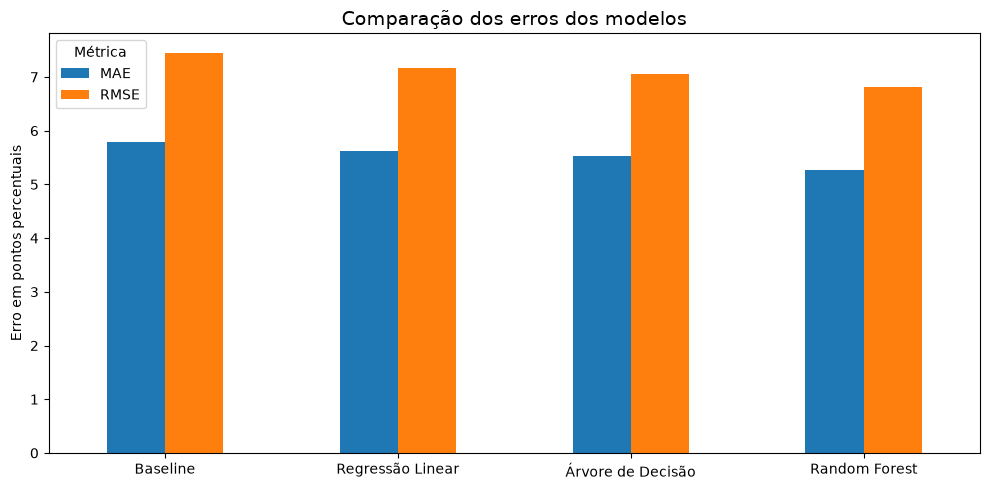

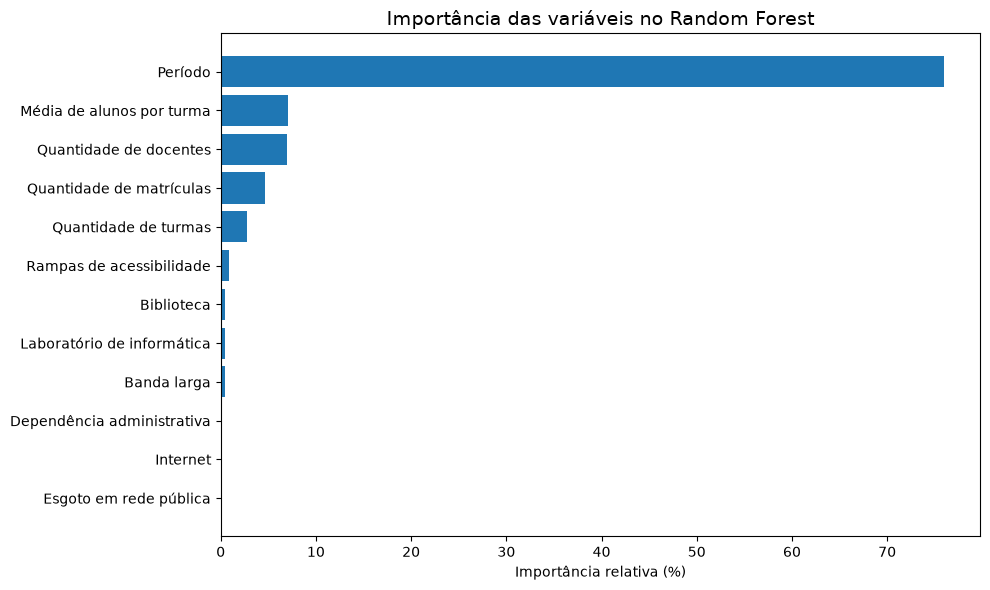

In [15]:
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Comparação de MAE e RMSE
# ------------------------------------------------------------

metricas_plot = (
    resultados_modelos[
        ["modelo", "MAE", "RMSE"]
    ]
    .set_index("modelo")
)

ax = metricas_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title(
    "Comparação dos erros dos modelos",
    fontsize=14
)

ax.set_xlabel("")
ax.set_ylabel("Erro em pontos percentuais")

plt.xticks(
    rotation=0
)

plt.legend(
    title="Métrica"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Importância consolidada das variáveis
# ------------------------------------------------------------

importancia_plot = (
    importancia_consolidada
    .sort_values(
        "importancia_percentual",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    importancia_plot["variavel_consolidada"],
    importancia_plot["importancia_percentual"]
)

plt.title(
    "Importância das variáveis no Random Forest",
    fontsize=14
)

plt.xlabel(
    "Importância relativa (%)"
)

plt.ylabel("")

plt.tight_layout()
plt.show()

## 15. Conclusão da modelagem preditiva

A etapa de modelagem teve como objetivo avaliar em que medida características escolares disponíveis na base analítica permitem estimar a taxa de aprovação das escolas públicas de Ensino Fundamental de Porto Alegre.

Foram comparados quatro cenários:

- baseline baseado na média histórica;
- Regressão Linear;
- Árvore de Decisão;
- Random Forest.

Os resultados no conjunto de teste de 2023 foram:

| Modelo | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline | 5,79 | 7,44 | -0,0005 |
| Regressão Linear | 5,62 | 7,16 | 0,0736 |
| Árvore de Decisão | 5,53 | 7,06 | 0,0975 |
| Random Forest | **5,27** | **6,82** | **0,1577** |

O **Random Forest apresentou o melhor desempenho**, com os menores valores de MAE e RMSE e o maior R² entre os modelos avaliados.

Em comparação com o baseline, o modelo reduziu o erro médio das previsões e apresentou maior capacidade de representar a variação observada na taxa de aprovação em 2023.

Apesar desse ganho, o valor de **R² igual a 0,1577** indica que a capacidade explicativa do modelo ainda é limitada. Isso sugere que as características disponíveis na base representam apenas parte dos fatores associados ao desempenho escolar.

A análise de importância das variáveis mostrou forte predominância do **período histórico**, responsável por aproximadamente **75,95% da importância consolidada do Random Forest**. Esse resultado está associado principalmente às mudanças expressivas observadas nas taxas de rendimento durante os anos de 2020 e 2021.

Entre as características escolares, destacaram-se:

- média de alunos por turma;
- quantidade de docentes;
- quantidade de matrículas;
- quantidade de turmas.

Os indicadores individuais de infraestrutura apresentaram menor contribuição relativa para a capacidade preditiva do modelo.

Esses resultados devem ser interpretados com cautela. A importância das variáveis indica contribuição para a previsão do modelo, mas não representa magnitude de efeito e não permite estabelecer relações de causa e efeito.

De forma geral, a modelagem confirma que as variáveis escolares utilizadas possuem alguma capacidade de estimar a taxa de aprovação, superando a média histórica como referência, mas também evidencia que o desempenho educacional depende de fatores mais amplos do que aqueles contemplados na base analisada.